In [1]:
import sys, platform, subprocess, datetime
import torch

print("===== Environment Info =====")
print("OS:", platform.platform())
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA (torch built with):", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU compute capability:", torch.cuda.get_device_capability(0))
    print("GPU total memory (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

try:
    import transformers
    print("transformers:", transformers.__version__)
except ImportError:
    print("transformers: not installed")

print("\n--- nvidia-smi (driver version included")
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

===== Environment Info =====
OS: Linux-6.6.122+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA (torch built with): 12.8
cuDNN version: 91900
GPU available: True
GPU name: Tesla T4
GPU compute capability: (7, 5)
GPU total memory (GB): 15.637086208
transformers: 5.13.1

--- nvidia-smi (driver version included
Tue Aug 18 01:01:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+===

In [ ]:
%cd "/content/drive/MyDrive/Project/nanoGPT/KV Cache/1_end_to_end_time_estimation/"

In [3]:
!python end_to_end_estimation_test_file.py

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True
overriding dropout rate to 0.0
number of parameters: 123.65M
config.json: 100% 665/665 [00:00<00:00, 3.48MB/s]

model.safetensors: downloading bytes:  67% 366M/548M [00:03<00:01, 140MB/s, 30.8MB/s  ]
model.safetensors: downloading bytes:  75% 408M/548M [00:03<00:01, 137MB/s, 34.6MB/s  ]
model.safetensors: downloading bytes:  83% 453M/548M [00:04<00:00, 168MB/s, 37.0MB/s  ]
model.safetensors: reconstructing file:  73% 402M/548M [00:04<00:01, 107MB/s, 30.7MB/s  ] 
model.safetensors: downloading bytes:  87% 474M/548M [00:04<00:00, 120MB/s, 39.5MB/s  ]
model.safetensors: downloading bytes: 100% 474M/474M [00:04<00:00, 105MB/s, 39.4MB/s  ]
model.safetensors: reconstructing file: 100% 548M/548M [00:04<00:00, 121MB/s, 48.4MB/s  ]
Loading weights: 100% 148/148 [00:00<00:00, 22346.27it/s]
generation_config.json: 100% 124/124 [00:00<00:00, 438kB/s]
===== running_mode = inf_no_cache =====
[inf_no_cache]

## Average time

In [6]:
import torch

# Define the path to the .pt file
file_path = '/content/drive/MyDrive/Project/nanoGPT/KV Cache/1_end_to_end_time_estimation/KV_cache_result/KV_Cache_wall_time_estimation.pt'

# Load the data from the .pt file
try:
    data = torch.load(file_path)
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
    data = None
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    data = None

if data:
    # Extract the time results
    time_results = data.get('time_result')

    if time_results:
        inf_no_cache_times = time_results.get('inf_no_cache')
        inf_cache_times = time_results.get('inf_cache')

        # Calculate the average for inf_no_cache
        if inf_no_cache_times and len(inf_no_cache_times) > 0:
            avg_inf_no_cache = sum(inf_no_cache_times) / len(inf_no_cache_times)
            print(f"Average time for inf_no_cache: {avg_inf_no_cache:.3f} seconds")
        else:
            print("No 'inf_no_cache' times found or list is empty.")

        # Calculate the average for inf_cache
        if inf_cache_times and len(inf_cache_times) > 0:
            avg_inf_cache = sum(inf_cache_times) / len(inf_cache_times)
            print(f"Average time for inf_cache: {avg_inf_cache:.3f} seconds")
        else:
            print("No 'inf_cache' times found or list is empty.")
    else:
        print("Key 'time_result' not found in the loaded data.")
else:
    print("Could not process data due to loading error.")

Average time for inf_no_cache: 17.471 seconds
Average time for inf_cache: 2.055 seconds


In [8]:
import numpy as np

if time_results:
    for mode, times in time_results.items():
        if times and len(times) > 0:
            mean_val = np.mean(times)
            std_val = np.std(times)
            p50_val = np.percentile(times, 50)
            p95_val = np.percentile(times, 95)
            p99_val = np.percentile(times, 99)
            min_val = np.min(times)
            max_val = np.max(times)

            print(f"\n--- Statistics for {mode} ---")
            print(f"Mean: {mean_val:.3f} s")
            print(f"Std: {std_val:.3f} s")
            print(f"p50 (Median): {p50_val:.3f} s")
            print(f"p95: {p95_val:.3f} s")
            print(f"p99: {p99_val:.3f} s")
            print(f"Min: {min_val:.3f} s")
            print(f"Max: {max_val:.3f} s")
        else:
            print(f"No times found for {mode}.")
else:
    print("Time results not available for statistics calculation.")


--- Statistics for inf_no_cache ---
Mean: 17.471 s
Std: 0.205 s
p50 (Median): 17.544 s
p95: 17.643 s
p99: 17.681 s
Min: 16.911 s
Max: 17.691 s

--- Statistics for inf_cache ---
Mean: 2.055 s
Std: 0.003 s
p50 (Median): 2.055 s
p95: 2.059 s
p99: 2.060 s
Min: 2.052 s
Max: 2.060 s


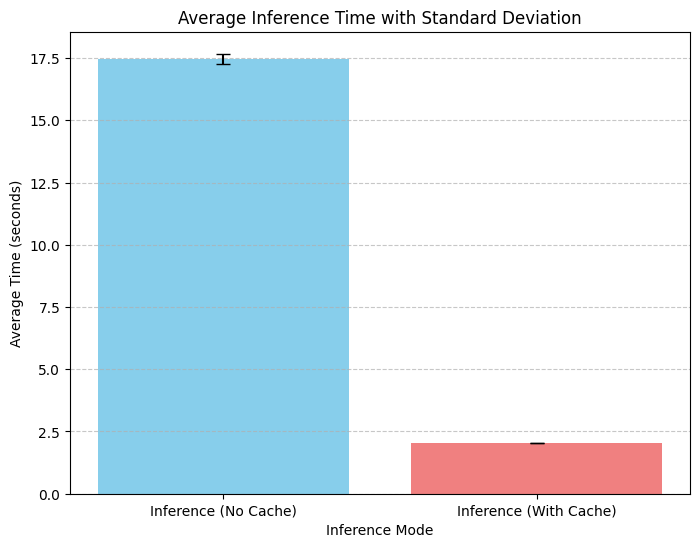

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# These variables (inf_no_cache_times, inf_cache_times, avg_inf_no_cache, avg_inf_cache)
# are available from the previous cell executions in the kernel state.

# Calculate standard deviations
std_inf_no_cache = np.std(inf_no_cache_times) if inf_no_cache_times else 0
std_inf_cache = np.std(inf_cache_times) if inf_cache_times else 0

# Create a DataFrame for plotting
data_for_plot = pd.DataFrame({
    'Mode': ['Inference (No Cache)', 'Inference (With Cache)'],
    'Average Time (s)': [avg_inf_no_cache, avg_inf_cache],
    'Standard Deviation (s)': [std_inf_no_cache, std_inf_cache]
})

plt.figure(figsize=(8, 6))

# Use matplotlib.pyplot.bar directly for more control
plt.bar(
    data_for_plot['Mode'],
    data_for_plot['Average Time (s)'],
    yerr=data_for_plot['Standard Deviation (s)'],
    capsize=5,  # Add caps to the error bars
    color=['skyblue', 'lightcoral'] # Specify colors for each bar
)

plt.title('Average Inference Time with Standard Deviation')
plt.ylabel('Average Time (seconds)')
plt.xlabel('Inference Mode')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()